# Country-Level Analysis

Goal:
- Top destination countries for German emigrants
- Which countries have the highest return rates
- How stable or volatile migration to specific countries is

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
# 02 Conig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [3]:
# 03 Load country dataset
df_country = pd.read_csv("../data/processed/return_rate_country.csv")

df_country.head()

,year,country,emigration,immigration,return_rate_country
0,2000,Afghanistan,16,13,0.812500
1,2000,Albanien,44,45,1.022727
2,2000,Algerien,75,64,0.853333
3,2000,Andorra,14,12,0.857143
4,2000,Angola,19,17,0.894737


In [4]:
df_country.info()

<class 'pandas.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 2924 non-null   int64  
 1   country              2924 non-null   str    
 2   emigration           2924 non-null   int64  
 3   immigration          2924 non-null   int64  
 4   return_rate_country  2896 non-null   float64
dtypes: float64(1), int64(3), str(1)
memory usage: 114.3 KB


### Data Cleaning

Return rates can contain infinite values when emigration equals zero.
These values are replaced with NaN to avoid distortions in the analysis.

In [5]:
df_country["return_rate_country"] = df_country["return_rate_country"].replace(
    [np.inf, -np.inf], np.nan
)
df_country.isna().sum()
df_country["return_rate_country"] = df_country["return_rate_country"].astype(float)

In [6]:
# Top Destination Countries
top_destinations = (
    df_country
    .groupby("country")["emigration"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_destinations

country
Ungeklärt / Ohne Angabe    1337683
Schweiz                     446118
Vereinigte Staaten          302241
Österreich                  256819
Polen                       191731
Vereinigtes Königreich      182548
Spanien                     175919
Frankreich                  160136
Türkei                      112906
Niederlande                  89775
Name: emigration, dtype: int64

<Axes: title={'center': 'Top Destination Countries for German Emigrants'}, xlabel='country'>

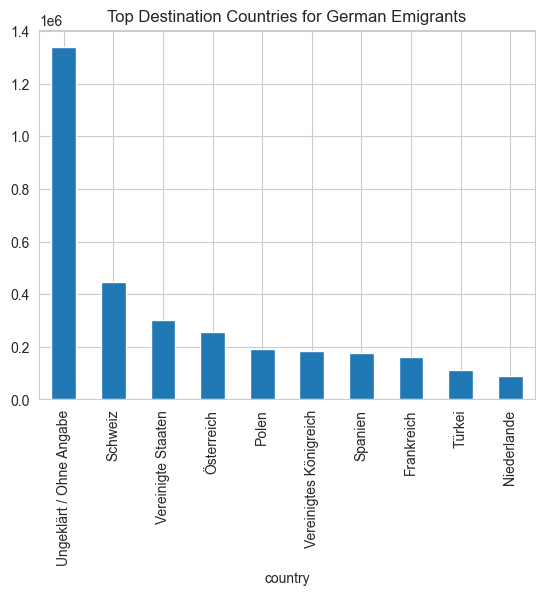

In [7]:
# Visual
top_destinations.plot(kind="bar", title="Top Destination Countries for German Emigrants")

### Top Destination Countries

The analysis shows the countries that received the highest number of German emigrants between 2000 and 2024.

This helps identify long-term migration preferences and potential economic or cultural migration corridors.

In [8]:
# Average Return Rate by Country
return_rate_country_avg = (
    df_country
    .groupby("country")["return_rate_country"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

return_rate_country_avg

country
Kasachstan                               16.234412
Kirgisistan                               9.145921
Usbekistan                                8.262336
Russische Föderation                      6.429067
Ukraine                                   5.949912
Sudan (ohne Südsudan) (ab 09.07.2011)     3.800000
Belarus                                   2.837353
Venezuela, Bolivarische Republik          2.351963
Jemen                                     2.187560
Armenien                                  2.134954
Name: return_rate_country, dtype: float64

<Axes: title={'center': 'Highest Average Return Rate by Country'}, xlabel='country'>

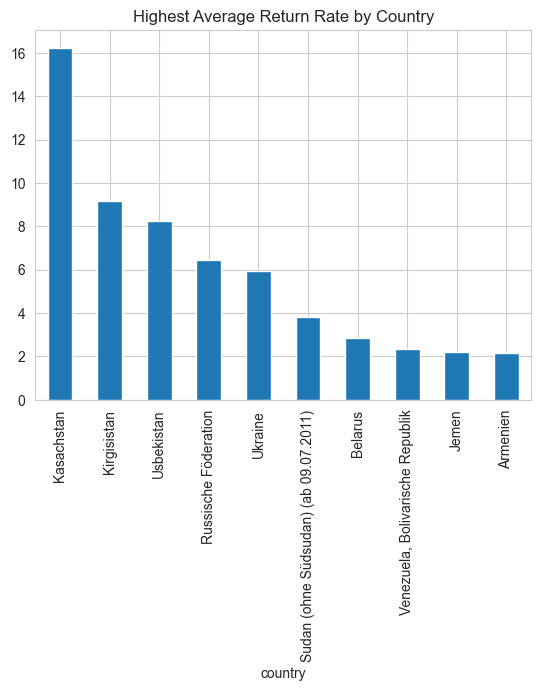

In [9]:
return_rate_country_avg.plot(kind="bar", title="Highest Average Return Rate by Country")

### Countries with Highest Return Rates

Some countries show significantly higher return rates, suggesting shorter migration cycles or temporary work migration patterns.

<Axes: title={'center': 'Migration Trends for Top Destination Countries'}, xlabel='year'>

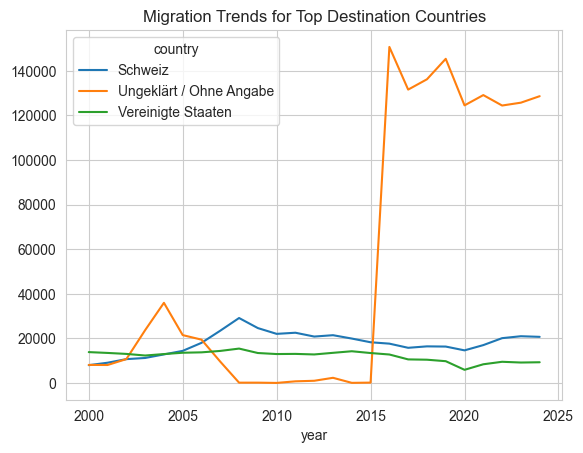

In [10]:
# Migration Trend of top 3 countries
top3 = top_destinations.index[:3]

df_top3 = df_country[df_country["country"].isin(top3)]

pivot_top3 = df_top3.pivot_table(
    index="year",
    columns="country",
    values="emigration"
)

pivot_top3.plot(title="Migration Trends for Top Destination Countries")

### Migration Trends for Major Destination Countries

The time-series analysis highlights how migration to major destinations evolved over time.

This allows identification of migration waves and potential external drivers.

## Top Destination Countries

To understand the main migration patterns, we first identify the countries with the highest total emigration from Germany.

In [11]:
top_countries = (
    df_country
    .groupby("country")["emigration"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

country
Ungeklärt / Ohne Angabe    1337683
Schweiz                     446118
Vereinigte Staaten          302241
Österreich                  256819
Polen                       191731
Vereinigtes Königreich      182548
Spanien                     175919
Frankreich                  160136
Türkei                      112906
Niederlande                  89775
Name: emigration, dtype: int64

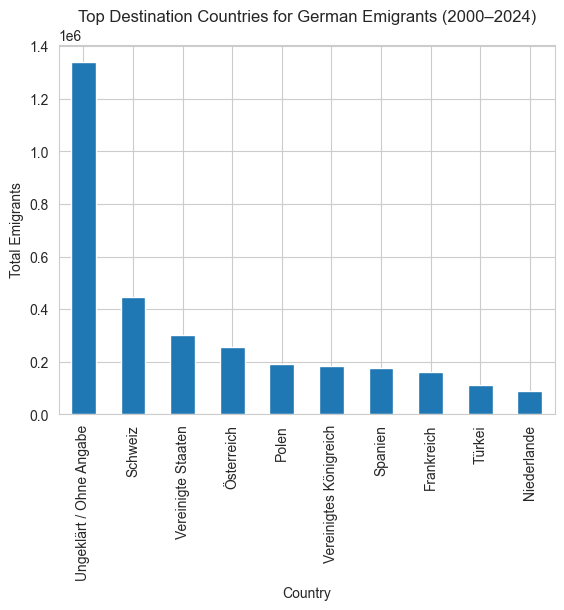

In [12]:
top_countries.plot(kind="bar")

plt.title("Top Destination Countries for German Emigrants (2000–2024)")
plt.ylabel("Total Emigrants")
plt.xlabel("Country")

plt.show()

In [13]:
# Top 10 destination countries

top10_list = top_countries.index.tolist()
df_top10 = df_country[df_country["country"].isin(top10_list)]

In [14]:
pivot_top10 = df_top10.pivot_table(
    index="year",
    columns="country",
    values="emigration"
)

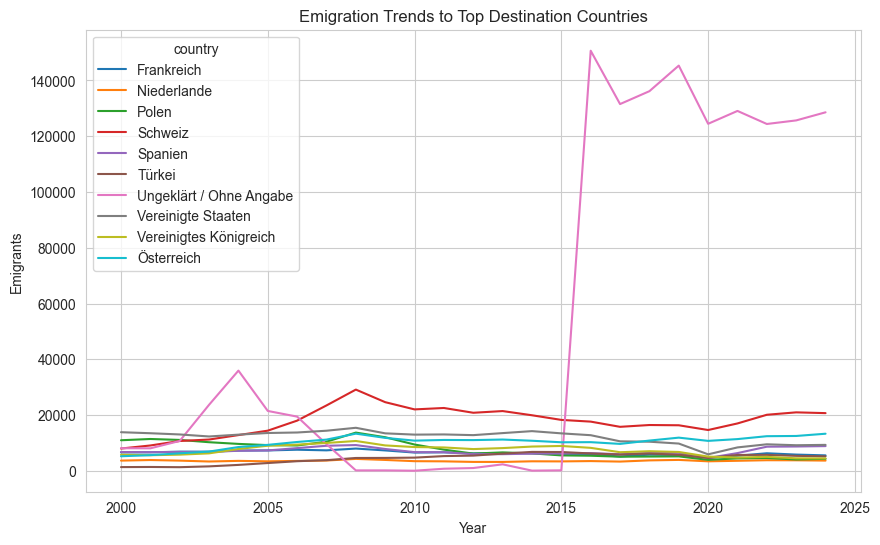

In [15]:
pivot_top10.plot(figsize=(10,6))

plt.title("Emigration Trends to Top Destination Countries")
plt.ylabel("Emigrants")
plt.xlabel("Year")

plt.show()

In [16]:
avg_return_rate = (
    df_country
    .groupby("country")["return_rate_country"]
    .mean()
    .sort_values(ascending=False)
)

avg_return_rate.head(10)

country
Kasachstan                               16.234412
Kirgisistan                               9.145921
Usbekistan                                8.262336
Russische Föderation                      6.429067
Ukraine                                   5.949912
Sudan (ohne Südsudan) (ab 09.07.2011)     3.800000
Belarus                                   2.837353
Venezuela, Bolivarische Republik          2.351963
Jemen                                     2.187560
Armenien                                  2.134954
Name: return_rate_country, dtype: float64

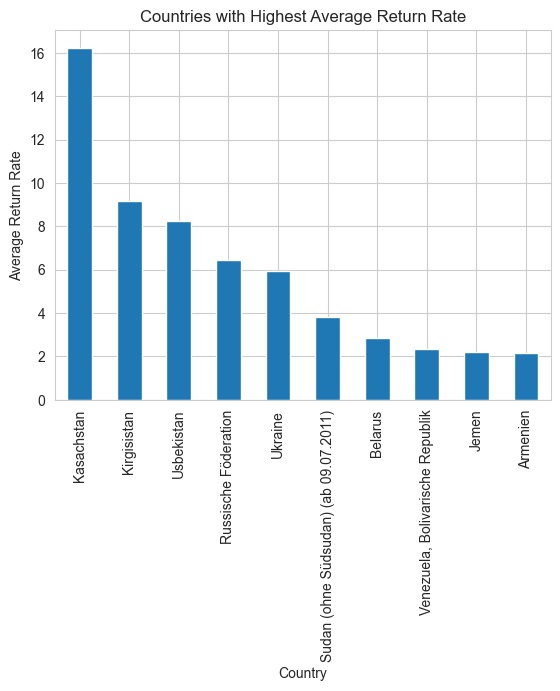

In [17]:
avg_return_rate.head(10).plot(kind="bar")

plt.title("Countries with Highest Average Return Rate")
plt.ylabel("Average Return Rate")
plt.xlabel("Country")

plt.show()

In [18]:
# lowest return rate
avg_return_rate.sort_values().head(10)

country
Schweiz                0.483694
Schweden               0.493011
Slowenien              0.530505
Norwegen               0.541250
Österreich             0.570535
Dänemark               0.587241
Unbekanntes Ausland    0.589379
Kanada                 0.632117
Finnland               0.642714
Island                 0.646386
Name: return_rate_country, dtype: float64

In [19]:
volatility = (
    df_country
    .groupby("country")["emigration"]
    .std()
    .sort_values(ascending=False)
)

volatility.head(10)

country
Ungeklärt / Ohne Angabe    61610.688312
Schweiz                     5078.599582
Polen                       2961.187674
Unbekanntes Ausland         2699.386185
Vereinigte Staaten          2292.557449
Österreich                  2210.303020
Vereinigtes Königreich      1832.934030
Türkei                      1786.200886
Spanien                     1160.163432
Kanada                       957.272964
Name: emigration, dtype: float64

## Country-Level Migration Analysis

This section explores migration patterns by destination country.

The analysis focuses on:

- Top destination countries for German emigrants
- Migration trends over time
- Average return rates by country
- Volatility of migration flows

## Methodological Break in 2016

The migration statistics show a sharp increase in emigration in 2016.

According to Destatis, this is mainly due to a **methodological change** in the migration statistics.

From 2016 onward, emigration cases with unknown destinations were systematically included and historical register corrections were implemented.

Therefore, the spike observed in 2016 should not be interpreted as an actual migration wave.

In [20]:
df_country[df_country["country"] == "Ungeklärt / Ohne Angabe"]

,year,country,emigration,immigration,return_rate_country
99,2000,Ungeklärt / Ohne Angabe,8113,8075,0.995316
216,2001,Ungeklärt / Ohne Angabe,8072,8096,1.002973
333,2002,Ungeklärt / Ohne Angabe,10716,8669,0.808977
450,2003,Ungeklärt / Ohne Angabe,23687,14151,0.597416
567,2004,Ungeklärt / Ohne Angabe,35947,41117,1.143823
684,2005,Ungeklärt / Ohne Angabe,21478,11144,0.518857
801,2006,Ungeklärt / Ohne Angabe,19442,9062,0.466104
918,2007,Ungeklärt / Ohne Angabe,9571,4209,0.439766
1035,2008,Ungeklärt / Ohne Angabe,153,693,4.529412
1152,2009,Ungeklärt / Ohne Angabe,158,554,3.506329


In [21]:
df_country["country"].unique()

<StringArray>
[                          'Afghanistan',
                              'Albanien',
                              'Algerien',
                               'Andorra',
                                'Angola',
                           'Argentinien',
                              'Armenien',
                         'Aserbaidschan',
                            'Australien',
                               'Belarus',
 ...
                               'Ägypten',
                             'Äthiopien',
                            'Österreich',
                        'Übriges Afrika',
                       'Übriges Amerika',
                         'Übriges Asien',
                        'Übriges Europa',
                      'Übriges Ozeanien',
 'Sudan (ohne Südsudan) (ab 09.07.2011)',
              'Südsudan (ab 09.07.2011)']
Length: 119, dtype: str

<Axes: xlabel='year'>

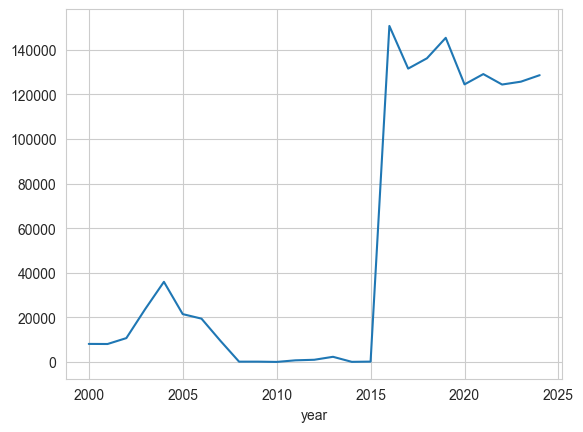

In [22]:
unknown_trend = (
    df_country[df_country["country"] == "Ungeklärt / Ohne Angabe"]
    .groupby("year")["emigration"]
    .sum()
)

unknown_trend.plot()

## Migration Concentration

Aggregated immigration per country

In [26]:
df_country_total = (
    df_country
    .groupby("country")[["immigration", "emigration"]]
    .sum()
    .reset_index()
)

df_country_total.head()

,country,immigration,emigration
0,Afghanistan,3633,2933
1,Albanien,1342,1317
2,Algerien,3860,3637
3,Andorra,297,307
4,Angola,583,542


In [27]:
df_country_total["immigration_share"] = (
    df_country_total["immigration"] /
    df_country_total["immigration"].sum()
)

In [28]:
hhi_immigration = (df_country_total["immigration_share"] ** 2).sum()

print("Immigration Concentration (HHI):", hhi_immigration)

Immigration Concentration (HHI): 0.0754106608823531


### HHI Interpretation
    < 0.10 Widely distributed immigration
    0.10–0.18 Moderate concentration
    > 0.18 High concentration

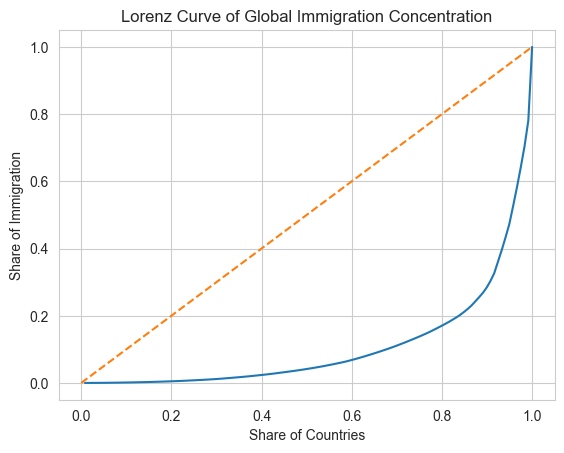

In [29]:
shares_sorted = np.sort(df_country_total["immigration_share"])
cum_shares = np.cumsum(shares_sorted)

countries = np.arange(1, len(shares_sorted)+1) / len(shares_sorted)

plt.plot(countries, cum_shares)
plt.plot([0,1],[0,1], linestyle="--")

plt.title("Lorenz Curve of Global Immigration Concentration")
plt.xlabel("Share of Countries")
plt.ylabel("Share of Immigration")

plt.show()

### Interpretation:
    Straight line → evenly distributed
    Sharp curve → a few countries dominate migration